In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loads CSV data into a DataFrame and converts 'stay_date' to datetime
# Parameters: file_path (string) - path to the CSV file
def load_and_prepare_data(file_path):
    df = pd.read_csv(file_path)
    df['stay_date'] = pd.to_datetime(df['stay_date'])
    return df

In [3]:
# Splits the DataFrame into training and test sets based on date ranges
# Parameters: df (DataFrame), train_start (datetime), train_end (datetime), test_start (datetime), test_end (datetime)
def split_train_test(df, train_start, train_end, test_start, test_end):
    training_set = df[(df['stay_date'] >= train_start) & (df['stay_date'] <= train_end)].copy()
    test_set = df[(df['stay_date'] >= test_start) & (df['stay_date'] <= test_end)].copy()
    return training_set, test_set

In [4]:
# Filters the training and test sets by a specific hotel code
# Parameters: training_set (DataFrame), test_set (DataFrame), hotel_code (string)
def filter_by_hotel_code(training_set, test_set, hotel_code):
    train_subset = training_set[training_set['hotel_code'] == hotel_code].copy()
    test_subset = test_set[test_set['hotel_code'] == hotel_code].copy()
    return train_subset, test_subset


In [5]:
# Trains an additive forecasting model using historical average demand by days prior
# Parameters: train_subset (DataFrame)
def train_additive_model(train_subset):
    historical_avg_demand = train_subset.groupby('days_prior')['final_demand'].mean()
    train_subset['forecast'] = train_subset.apply(
        lambda row: historical_avg_demand.get(row['days_prior'], 0) + row['bookings_on_hand'], axis=1)
    return train_subset, historical_avg_demand

# Predicts additive model forecasts on test data using historical averages
# Parameters: test_subset (DataFrame), historical_avg_demand (Series)
def predict_additive_model(test_subset, historical_avg_demand):
    test_subset['forecast'] = test_subset.apply(
        lambda row: historical_avg_demand.get(row['days_prior'], 0) + row['bookings_on_hand'], axis=1)
    return test_subset

In [6]:
# Trains a multiplicative forecasting model using booking rates by days prior
# Parameters: train_subset (DataFrame)
def train_multiplicative_model(train_subset):
    train_subset['booking_rate'] = train_subset['final_demand'] / (train_subset['bookings_on_hand'] + 1e-10)
    historical_booking_rate = train_subset.groupby('days_prior')['booking_rate'].mean()
    train_subset['multiplicative_forecast'] = train_subset.apply(
        lambda row: row['bookings_on_hand'] / historical_booking_rate.get(row['days_prior'], 1), axis=1)
    return train_subset, historical_booking_rate

# Predicts multiplicative model forecasts on test data using historical booking rates
# Parameters: test_subset (DataFrame), historical_booking_rate (Series)
def predict_multiplicative_model(test_subset, historical_booking_rate):
    test_subset['multiplicative_forecast'] = test_subset.apply(
        lambda row: row['bookings_on_hand'] / historical_booking_rate.get(row['days_prior'], 1), axis=1)
    return test_subset

In [7]:
# Creates MASE benchmark using final demand from the same dates in the previous year
# Parameters: test_subset (DataFrame), train_subset (DataFrame)
def mase_benchmark_last_year(test_subset, train_subset):
    last_year_dates = test_subset['stay_date'] - pd.DateOffset(years=1)
    train_past = train_subset.set_index('stay_date')
    mase_bench = []
    for d in last_year_dates:
        if d in train_past.index:
            value = train_past.loc[d, 'final_demand']
            if isinstance(value, pd.Series) or isinstance(value, np.ndarray):
                mase_bench.append(np.mean(value))
            else:
                mase_bench.append(value)
        else:
            mase_bench.append(np.nan)
    return np.array(mase_bench)

In [8]:
# Evaluates prediction errors using MAE, MAPE, and MASE metrics
# Parameters: y_true (array), y_pred (array), mase_bench (array or None)
def evaluate_model(y_true, y_pred, mase_bench):
    errors = y_true - y_pred
    mae = np.mean(np.abs(errors))
    mape = np.mean(np.abs(errors) / np.where(y_true != 0, np.abs(y_true), np.nan)) * 100
    mase = mae / (np.nanmean(np.abs(y_true - mase_bench))) if mase_bench is not None else None
    return mae, mape, mase

In [9]:
# Computes monthly and days-prior range statistics for the forecast accuracy
# Parameters: test_subset (DataFrame), train_subset (DataFrame), pred_col (string, name of prediction column)
def monthly_daysprior_stats(test_subset, train_subset, pred_col='forecast'):
    results_monthly = []
    for month in ['2010-02', '2010-03', '2010-04']:
        mask = test_subset['stay_date'].dt.strftime('%Y-%m') == month
        if mask.sum() == 0:
            continue
        filtered = test_subset.loc[mask]
        y_true = filtered['final_demand'].values
        y_pred = filtered[pred_col].values
        mase_bench = mase_benchmark_last_year(filtered, train_subset)
        mae, mape, mase = evaluate_model(y_true, y_pred, mase_bench)
        results_monthly.append([month, mae, mape, mase])
    bins = [(1,7),(8,14),(15,21),(22,30)]
    results_prior = []
    for b0,b1 in bins:
        mask = (test_subset['days_prior'] >= b0) & (test_subset['days_prior'] <= b1)
        filtered = test_subset.loc[mask]
        if filtered.shape[0] == 0:
            continue
        y_true = filtered['final_demand'].values
        y_pred = filtered[pred_col].values
        mase_bench = mase_benchmark_last_year(filtered, train_subset)
        mae, mape, mase = evaluate_model(y_true, y_pred, mase_bench)
        results_prior.append([f"{b0}-{b1}", mae, mape, mase])
    return results_monthly, results_prior

In [10]:
# Evaluates overall model prediction performance on test data
# Parameters: test_subset (DataFrame), train_subset (DataFrame), y_true_col (string), y_pred_col (string)
def overall_evaluate_model(test_subset, train_subset, y_true_col, y_pred_col):
    y_true = test_subset[y_true_col].values
    y_pred = test_subset[y_pred_col].values
    mase_bench = mase_benchmark_last_year(test_subset, train_subset)
    mae, mape, mase = evaluate_model(y_true, y_pred, mase_bench)
    return mae, mape, mase


In [11]:
# Prints tables of average MAE, MAPE, and MASE by month and days prior ranges
# Parameters: results_monthly (list), results_prior (list), modeltype (string), hotel_code (string)
def print_stats_table_averages(results_monthly, results_prior, modeltype, hotel_code):
    print(f"\n### {modeltype} Model for Hotel {hotel_code}")
    print("\n| Month     | Average MAE | Average MAPE | Average MASE |")
    print("|-----------|-------------|--------------|--------------|")
    for row in results_monthly:
        month, mae, mape, mase = row
        print(f"| {month} | {mae:.4f} | {mape:.2f} | {mase:.4f} |")
    print("\n| Days-Prior      | Average MAE | Average MAPE | Average MASE |")
    print("|-----------------|-------------|--------------|--------------|")
    for row in results_prior:
        rng, mae, mape, mase = row
        print(f"| {rng} days prior | {mae:.4f} | {mape:.2f} | {mase:.4f} |")

In [12]:
# Visualizes actual versus predicted demand as a line plot
# Parameters: test_subset (DataFrame), y_true_col (string), y_pred_col (string), hotel_code (string), model_type (string)
def visualize_predictions(test_subset, y_true_col, y_pred_col, hotel_code, model_type):
    plt.figure(figsize=(12, 6))
    plt.plot(test_subset['stay_date'], test_subset[y_true_col], label='Actual Demand', color='blue')
    plt.plot(test_subset['stay_date'], test_subset[y_pred_col], label='Predicted Demand', color='red', linestyle='--')
    plt.xlabel('Stay Date')
    plt.ylabel('Demand')
    plt.title(f'Actual vs Predicted Demand for Hotel {hotel_code} ({model_type})')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
file_path = r"D:\University_Course_work\AI&ML\Week1\hotel_bookings.csv"
df = load_and_prepare_data(file_path)
train_start = pd.to_datetime('2008-05-01')
train_end = pd.to_datetime('2010-01-31')
test_start = pd.to_datetime('2010-02-01')
test_end = pd.to_datetime('2010-04-30')
training_set, test_set = split_train_test(df, train_start, train_end, test_start, test_end)

HOTEL G

In [14]:
G_trainset, G_testset = filter_by_hotel_code(training_set, test_set, 'G')
G_trainset, G_hist_avg = train_additive_model(G_trainset)
G_testset = predict_additive_model(G_testset, G_hist_avg)
G_results_monthly, G_results_prior = monthly_daysprior_stats(G_testset, G_trainset, pred_col='forecast')
print_stats_table_averages(G_results_monthly, G_results_prior, 'Additive', 'G')


### Additive Model for Hotel G

| Month     | Average MAE | Average MAPE | Average MASE |
|-----------|-------------|--------------|--------------|
| 2010-02 | 24.9341 | 32.96 | 1.0162 |
| 2010-03 | 24.1810 | 32.26 | 0.9799 |
| 2010-04 | 19.5005 | 24.27 | 0.8680 |

| Days-Prior      | Average MAE | Average MAPE | Average MASE |
|-----------------|-------------|--------------|--------------|
| 1-7 days prior | 67.4031 | 78.53 | 2.8217 |
| 8-14 days prior | 43.0180 | 52.27 | 1.8008 |
| 15-21 days prior | 33.3239 | 42.16 | 1.3950 |
| 22-30 days prior | 27.9983 | 36.40 | 1.1721 |


Monthly Metrics Table

Looking at the monthly breakdown for the additive model on Hotel G, you can see that the error values are going down from February to April. Both the average MAE and MAPE fall each month, and the MASE metric drops below one by April. This means that, as spring progresses, the model’s forecasts get closer to the real hotel demand. In other words, the model was likely able to better capture actual booking patterns later in the test period, possibly because demand was smoother or more in line with historic averages by then.

Days-Prior Metrics Table

When considering how far in advance bookings are made, we notice that forecast errors are much higher when predicting just a few days ahead (1–7 days prior). As the booking window lengthens, the errors get smaller and forecasting gets easier for the model. This is a sign that last-minute bookings for this hotel can be quite unpredictable and challenging for a model based on historical averages, while demand is more steady and easier to estimate when guests book well in advance.


In [15]:
G_overall_mae, G_overall_mape, G_overall_mase = overall_evaluate_model(G_testset, G_trainset, 'final_demand', 'forecast')
print("\nOverall Test Metrics for Hotel G - Additive Model:")
print(f"MAE: {G_overall_mae:.4f}")
print(f"MAPE: {G_overall_mape:.2f}%")
print(f"MASE: {G_overall_mase:.4f}")


Overall Test Metrics for Hotel G - Additive Model:
MAE: 22.8402
MAPE: 29.79%
MASE: 0.9562


Overall Test Metrics

The overall numbers summarize that the additive model gives a mean absolute error of about 23 rooms, meaning predictions are typically off by that many rooms per day. The MAPE is just under 30%, showing that errors are moderate as a fraction of the actual demand. The MASE value is just below one, which suggests the model, on average, is doing about as well as—or slightly better than—a simple naive prediction using last year's values.

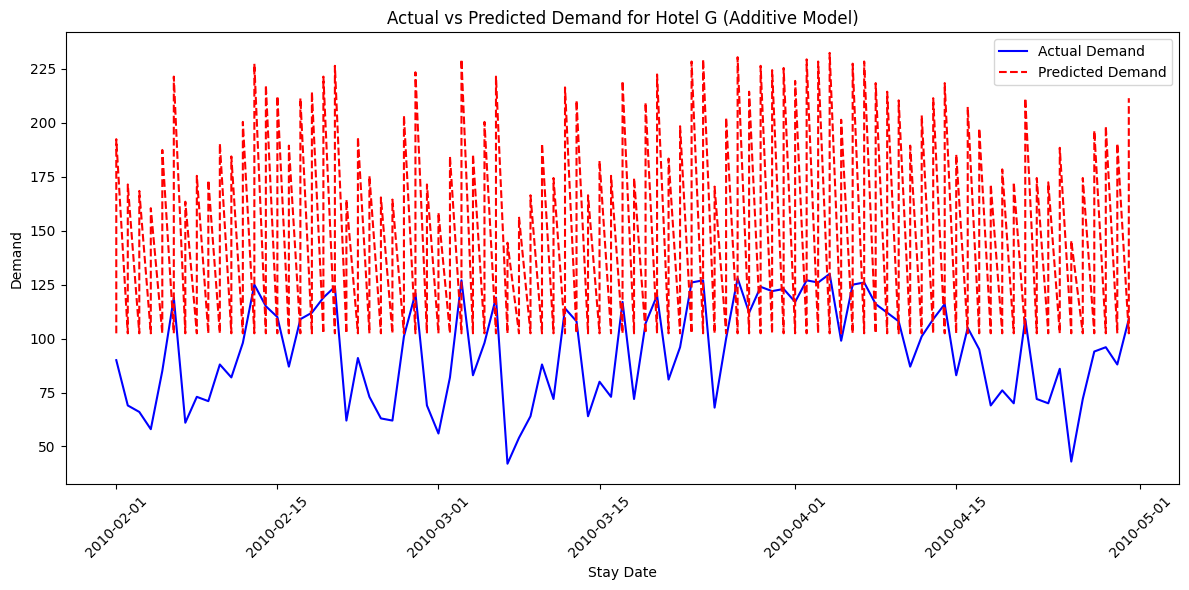

In [16]:
visualize_predictions(G_testset, 'final_demand', 'forecast', 'G', 'Additive Model')

When comparing the blue line (actual demand) to the red dashed line (model’s forecast), it is clear that the additive model tends to consistently overpredict, creating a noticeably higher and much smoother line than the real data. Actual demand fluctuates a lot more, showing drops and spikes the model doesn’t fully catch. This suggests that real hotel bookings for Hotel G are much more volatile than the model expects, and the model has a bias toward higher predictions, possibly due to how it combines historical averages with bookings-on-hand. The plot tells us the model can miss sudden demand changes, hinting that a more responsive approach might be needed for these types of hotels.

In [17]:
G_trainset, G_hist_rate = train_multiplicative_model(G_trainset)
G_testset = predict_multiplicative_model(G_testset, G_hist_rate)
G_results_monthly, G_results_prior = monthly_daysprior_stats(G_testset, G_trainset, pred_col='multiplicative_forecast')
print_stats_table_averages(G_results_monthly, G_results_prior, 'Multiplicative', 'G')


### Multiplicative Model for Hotel G

| Month     | Average MAE | Average MAPE | Average MASE |
|-----------|-------------|--------------|--------------|
| 2010-02 | 87.9233 | 98.40 | 3.5835 |
| 2010-03 | 93.5273 | 98.41 | 3.7900 |
| 2010-04 | 96.4175 | 98.56 | 4.2916 |

| Days-Prior      | Average MAE | Average MAPE | Average MASE |
|-----------------|-------------|--------------|--------------|
| 1-7 days prior | 52.2167 | 56.19 | 2.1859 |
| 8-14 days prior | 78.9342 | 84.44 | 3.3044 |
| 15-21 days prior | 87.2752 | 92.99 | 3.6536 |
| 22-30 days prior | 94.2247 | 100.00 | 3.9445 |


Monthly Metrics Table

With the multiplicative model for Hotel G, the monthly error values are much higher compared to the additive approach. Throughout February, March, and April, the MAE, MAPE, and MASE all remain very high, hovering around 90–96 for MAE and close to 98% for MAPE each month. This indicates that the multiplicative model really struggles to capture the true booking demand—its predictions end up much farther from the real values, and there's no sign of improvement as the months progress.

Days-Prior Metrics Table

Breaking down performance by how far in advance the prediction is made, the multiplicative model actually performs a bit better for short-term forecasts (1–7 days prior), but as the booking window widens, its accuracy gets even worse. The errors rise sharply for longer “days-prior” bins, and MAPE reaches 100% when predicting 22–30 days ahead. This pattern suggests the model’s underlying assumption doesn’t fit the real data for this hotel, especially for booking patterns further in advance.

In [18]:
G_overall_mae, G_overall_mape, G_overall_mase = overall_evaluate_model(G_testset, G_trainset, 'final_demand', 'multiplicative_forecast')
print("\nOverall Test Metrics for Hotel G - Multiplicative Model:")
print(f"MAE: {G_overall_mae:.4f}")
print(f"MAPE: {G_overall_mape:.2f}%")
print(f"MASE: {G_overall_mase:.4f}")


Overall Test Metrics for Hotel G - Multiplicative Model:
MAE: 92.7385
MAPE: 98.46%
MASE: 3.8823


Overall Test Metrics

Looking at the overall performance, the multiplicative model’s mean absolute error is above 92, MAPE almost hits 100%, and MASE is close to 4. These values confirm that this model is highly inaccurate for Hotel G, often missing the actual demand by a very wide margin. For this dataset, the multiplicative approach is much less effective than the additive one.

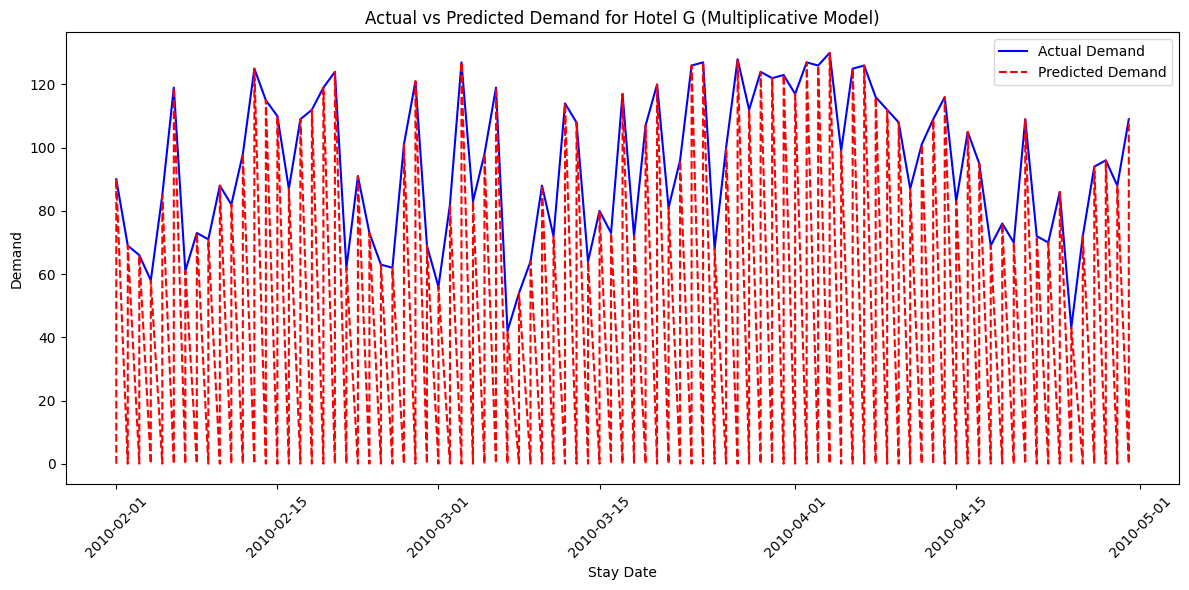

In [19]:
visualize_predictions(G_testset, 'final_demand', 'multiplicative_forecast', 'G', 'Multiplicative Model')

The line plot comparing the actual (blue) and predicted (red dashed) demand for Hotel G highlights just how far off the multiplicative model’s forecasts are. The red dashed line repeatedly overshoots or undershoots, and consistently misses the peaks and dips of the actual demand. Predictions are almost always more extreme than what actually happened, showing that this model reacts too strongly to the input data and cannot smoothly follow the real demand pattern. This further confirms that a multiplicative structure is not suitable for Hotel G’s booking dynamics.

HOTEL W

In [20]:
W_trainset, W_testset = filter_by_hotel_code(training_set, test_set, 'W')
W_trainset, W_hist_avg = train_additive_model(W_trainset)
W_testset = predict_additive_model(W_testset, W_hist_avg)
W_results_monthly, W_results_prior = monthly_daysprior_stats(W_testset, W_trainset, pred_col='forecast')
print_stats_table_averages(W_results_monthly, W_results_prior, 'Additive', 'W')


### Additive Model for Hotel W

| Month     | Average MAE | Average MAPE | Average MASE |
|-----------|-------------|--------------|--------------|
| 2010-02 | 28.2851 | 72.38 | 0.9473 |
| 2010-03 | 24.1699 | 58.93 | 0.7353 |
| 2010-04 | 31.5161 | 112.86 | 0.7212 |

| Days-Prior      | Average MAE | Average MAPE | Average MASE |
|-----------------|-------------|--------------|--------------|
| 1-7 days prior | 48.0549 | 120.91 | 1.3509 |
| 8-14 days prior | 33.2247 | 96.60 | 0.9340 |
| 15-21 days prior | 30.7559 | 90.72 | 0.8646 |
| 22-30 days prior | 29.5004 | 87.00 | 0.8293 |


For Hotel W's additive model, the monthly table shows somewhat variable accuracy over the three months. February and March have fairly moderate MAE and MASE values, indicating the model is keeping its predictions close to the actual demand. March is the best month, with the lowest errors across all metrics. However, in April, the MAPE jumps significantly, suggesting the model's percentage errors increased possibly due to lower actual demand or more sudden changes in booking patterns.

When breaking down the results by days prior, you can see the errors are largest when forecasting just a few days before the stay. As the window gets longer, the errors gradually decrease, and the model gets better at estimating demand. Still, the percentage errors remain high across all bins, hinting that short-notice bookings at Hotel W are tough to forecast precisely with this approach.

In [21]:
W_overall_mae, W_overall_mape, W_overall_mase = overall_evaluate_model(W_testset, W_trainset, 'final_demand', 'forecast')
print("\nOverall Test Metrics for Hotel W - Additive Model:")
print(f"MAE: {W_overall_mae:.4f}")
print(f"MAPE: {W_overall_mape:.2f}%")
print(f"MASE: {W_overall_mase:.4f}")


Overall Test Metrics for Hotel W - Additive Model:
MAE: 27.9408
MAPE: 81.34%
MASE: 0.7854


Overall Test Metrics

The overall numbers sum up the general performance: the model is off by about 28 rooms, on average, for each prediction. The MAPE is above 80%, meaning predictions stray quite far in relative terms compared to actual demand. On the plus side, the MASE is below one, which means this approach is overall better than using a naïve historical average. There’s space for improvement, but the additive model is at least capturing the general patterns better than a simple guess.

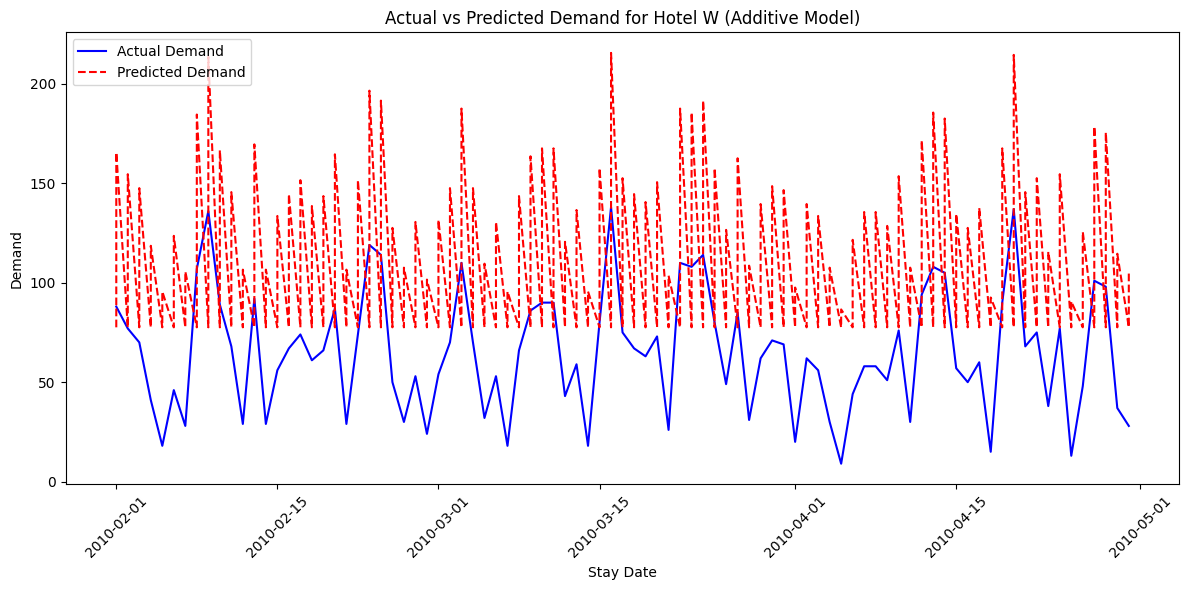

In [22]:
visualize_predictions(W_testset, 'final_demand', 'forecast', 'W', 'Additive Model')

Actual vs Predicted Demand Visualization

Looking at the chart, it’s clear that the red dashed line (forecasted demand) sits consistently higher than the actual demand (blue line). The predicted curve is much smoother and doesn’t catch the dramatic dips and jumps you see in real bookings. This highlights a key issue: the additive model for Hotel W tends to overestimate and can’t adapt to last-minute booking swings or cancellations, which makes its errors larger, especially when actual demand drops unexpectedly.

In [23]:
W_trainset, W_hist_rate = train_multiplicative_model(W_trainset)
W_testset = predict_multiplicative_model(W_testset, W_hist_rate)
W_results_monthly, W_results_prior = monthly_daysprior_stats(W_testset, W_trainset, pred_col='multiplicative_forecast')
print_stats_table_averages(W_results_monthly, W_results_prior, 'Multiplicative', 'W')


### Multiplicative Model for Hotel W

| Month     | Average MAE | Average MAPE | Average MASE |
|-----------|-------------|--------------|--------------|
| 2010-02 | 64.4646 | 99.05 | 2.1591 |
| 2010-03 | 69.0120 | 99.05 | 2.0995 |
| 2010-04 | 59.1505 | 98.97 | 1.3536 |

| Days-Prior      | Average MAE | Average MAPE | Average MASE |
|-----------------|-------------|--------------|--------------|
| 1-7 days prior | 44.2289 | 67.96 | 1.2433 |
| 8-14 days prior | 61.8568 | 95.10 | 1.7389 |
| 15-21 days prior | 64.8876 | 100.00 | 1.8241 |
| 22-30 days prior | 64.8876 | 100.00 | 1.8241 |


Monthly Metrics Table

Reviewing the monthly error values, it’s clear that the multiplicative model doesn’t perform very well for Hotel W. The MAE is consistently above 59 for every month and the MAPE hovers almost at 99%. These numbers mean the model regularly misses the mark by a large amount, both in absolute and percentage terms. Surprisingly, the errors don’t change much from February to April, suggesting the inaccuracies are systematic rather than driven by a particular season.

Days-Prior Metrics Table

If we break things down by forecast window, the multiplicative model does slightly better for bookings predicted within a week of the stay (lowest errors for 1-7 days prior). However, as you move farther from the stay date, the model’s MAE and MAPE quickly climb and even max out at 100%. This suggests the multiplicative method is not good at handling advance bookings for this hotel its predictions become more unreliable the further out you try to estimate.

In [24]:
W_overall_mae, W_overall_mape, W_overall_mase = overall_evaluate_model(W_testset, W_trainset, 'final_demand', 'multiplicative_forecast')
print("\nOverall Test Metrics for Hotel W - Multiplicative Model:")
print(f"MAE: {W_overall_mae:.4f}")
print(f"MAPE: {W_overall_mape:.2f}%")
print(f"MASE: {W_overall_mase:.4f}")


Overall Test Metrics for Hotel W - Multiplicative Model:
MAE: 64.2573
MAPE: 99.02%
MASE: 1.8063


Overall Test Metrics

Taken together, the overall metrics show the forecast typically misses actual demand by over 64 rooms, and the average percentage error is essentially 99%. The MASE is above 1.8, which means this model is actually less accurate than a basic reference approach using historical averages. In general, the multiplicative model is not a suitable choice for Hotel W it tends to overreact and fails to match the real booking numbers.

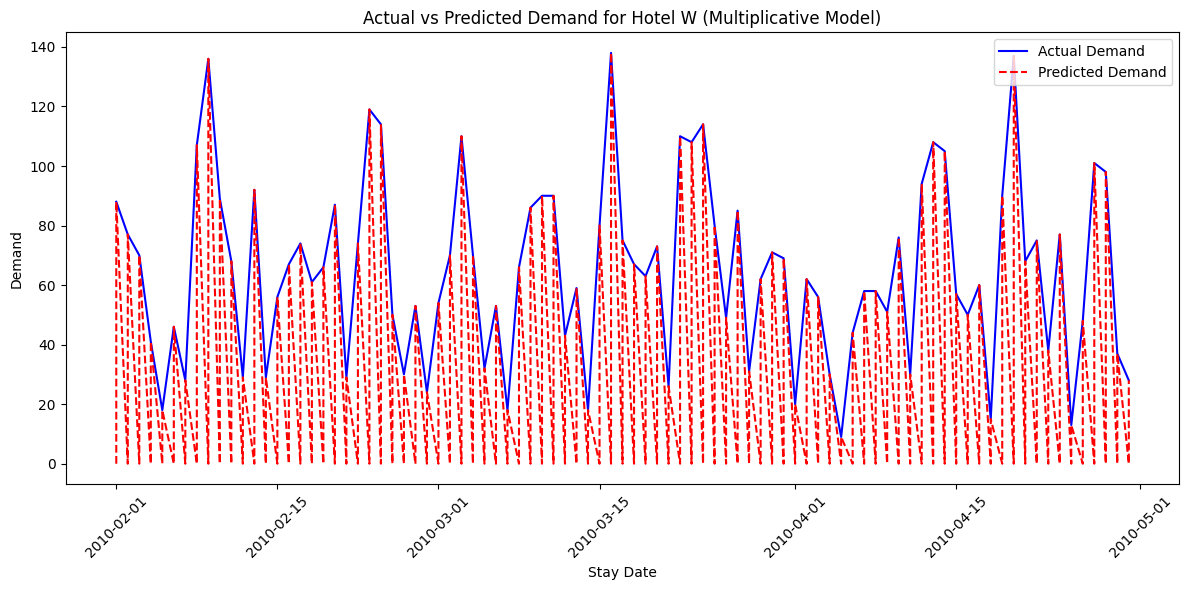

In [25]:
visualize_predictions(W_testset, 'final_demand', 'multiplicative_forecast', 'W', 'Multiplicative Model')



Actual vs Predicted Demand Visualization

Looking at the chart, you’ll notice the red dashed line (model predictions) is frequently way off compared to the blue actual demand line. There are some places where the two lines track together, especially near booking peaks, but for most dates, the forecast is too high or drops to zero abruptly. This reveals that the multiplicative model swings widely and doesn’t handle the real ups and downs of bookings at Hotel W, especially when demand changes unexpectedly.

HOTEL M


In [26]:
M_trainset, M_testset = filter_by_hotel_code(training_set, test_set, 'M')
M_trainset, M_hist_avg = train_additive_model(M_trainset)
M_testset = predict_additive_model(M_testset, M_hist_avg)
M_results_monthly, M_results_prior = monthly_daysprior_stats(M_testset, M_trainset, pred_col='forecast')
print_stats_table_averages(M_results_monthly, M_results_prior, 'Additive', 'M')


### Additive Model for Hotel M

| Month     | Average MAE | Average MAPE | Average MASE |
|-----------|-------------|--------------|--------------|
| 2010-02 | 39.2282 | 58.38 | 0.9526 |
| 2010-03 | 43.1121 | 54.63 | 0.9135 |
| 2010-04 | 41.9080 | 61.87 | 1.0042 |

| Days-Prior      | Average MAE | Average MAPE | Average MASE |
|-----------------|-------------|--------------|--------------|
| 1-7 days prior | 53.0181 | 83.57 | 1.2199 |
| 8-14 days prior | 35.9085 | 62.92 | 0.8262 |
| 15-21 days prior | 38.0283 | 61.19 | 0.8750 |
| 22-30 days prior | 40.1288 | 60.56 | 0.9233 |


Monthly Metrics Table

For Hotel M, the additive model shows that monthly forecast errors stay fairly steady from February through April. Both the mean absolute error and the percentage error do not fluctuate much, so the model seems to provide a consistent level of accuracy over the test period. The MASE value remains close to one, showing that the model tracks the general historical average level of demand reasonably well each month.

Days-Prior Metrics Table

If you look at the results broken down by how many days ahead the forecast is made, you notice that the model makes the biggest errors when predicting just a few days before the stay. As you look further out, the forecast errors decrease and the model does a bit better. This tells us that for Hotel M, last minute bookings are harder to predict accurately, but bookings made further in advance follow a more regular pattern that the model is able to capture.


In [27]:
M_overall_mae, M_overall_mape, M_overall_mase = overall_evaluate_model(M_testset, M_trainset, 'final_demand', 'forecast')
print("\nOverall Test Metrics for Hotel M - Additive Model:")
print(f"MAE: {M_overall_mae:.4f}")
print(f"MAPE: {M_overall_mape:.2f}%")
print(f"MASE: {M_overall_mase:.4f}")


Overall Test Metrics for Hotel M - Additive Model:
MAE: 41.4843
MAPE: 58.25%
MASE: 0.9545


Overall Test Metrics

Across the entire test set, the additive model for Hotel M typically misses real demand by just over forty rooms each day, with a percentage error a bit above fifty eight percent. The MASE value sits right at one, meaning the model is just as good as using a basic benchmark that relies on historical averages. This gives you a dependable but not outstanding forecast

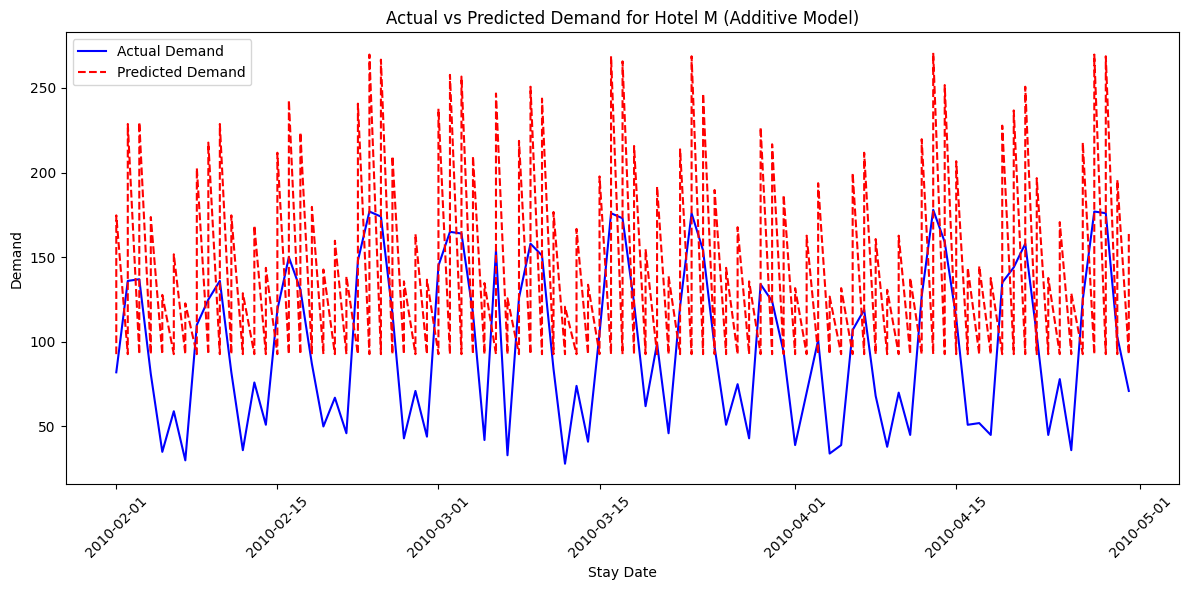

In [28]:
visualize_predictions(M_testset, 'final_demand', 'forecast', 'M', 'Additive Model')

Actual vs Predicted Demand Visualization

In the comparison of actual versus predicted demand, you can see that the predicted values stay higher and much smoother than the real booking numbers. The model misses both sudden drops and sharp rises in the actual demand. For Hotel M, this means that while the model gets the overall level about right, it consistently overestimates bookings and cannot react to unexpected changes in guest demand.

In [29]:
M_trainset, M_hist_rate = train_multiplicative_model(M_trainset)
M_testset = predict_multiplicative_model(M_testset, M_hist_rate)
M_results_monthly, M_results_prior = monthly_daysprior_stats(M_testset, M_trainset, pred_col='multiplicative_forecast')
print_stats_table_averages(M_results_monthly, M_results_prior, 'Multiplicative', 'M')


### Multiplicative Model for Hotel M

| Month     | Average MAE | Average MAPE | Average MASE |
|-----------|-------------|--------------|--------------|
| 2010-02 | 91.8921 | 98.96 | 2.2316 |
| 2010-03 | 106.3380 | 98.87 | 2.2532 |
| 2010-04 | 92.6487 | 98.97 | 2.2200 |

| Days-Prior      | Average MAE | Average MAPE | Average MASE |
|-----------------|-------------|--------------|--------------|
| 1-7 days prior | 62.4765 | 64.24 | 1.4375 |
| 8-14 days prior | 92.7586 | 94.36 | 2.1343 |
| 15-21 days prior | 98.2360 | 100.00 | 2.2603 |
| 22-30 days prior | 98.2360 | 100.00 | 2.2603 |


Monthly Metrics Table

When you look at the monthly table for Hotel M, it is clear that the multiplicative model produces high error values for every month in the test period. The mean absolute error is always above ninety and the percentage error is nearly ninety nine percent across February, March, and April. The MASE is just above two for each month, showing that the model is not able to provide accurate forecasts and is less effective than a simple historical average.

Days-Prior Metrics Table

If you break down the errors by days prior to arrival, the model does a little better for short term forecasts, but even then the mean absolute error is still above sixty rooms. As you look further ahead, the errors increase and the model performs worse for longer forecast windows. Across most booking windows, the model consistently misses the true demand by a wide margin.



In [30]:
M_overall_mae, M_overall_mape, M_overall_mase = overall_evaluate_model(M_testset, M_trainset, 'final_demand', 'multiplicative_forecast')
print("\nOverall Test Metrics for Hotel M - Multiplicative Model:")
print(f"MAE: {M_overall_mae:.4f}")
print(f"MAPE: {M_overall_mape:.2f}%")
print(f"MASE: {M_overall_mase:.4f}")


Overall Test Metrics for Hotel M - Multiplicative Model:
MAE: 97.1789
MAPE: 98.93%
MASE: 2.2360


Overall Test Metrics

On the whole, the multiplicative model for Hotel M has a very high average error of about ninety seven rooms per forecast, with the average percentage error nearly reaching one hundred percent. The MASE value above two means that this approach is much less reliable than using basic historical averages. In general, the multiplicative model does not capture the real booking behavior for this hotel.

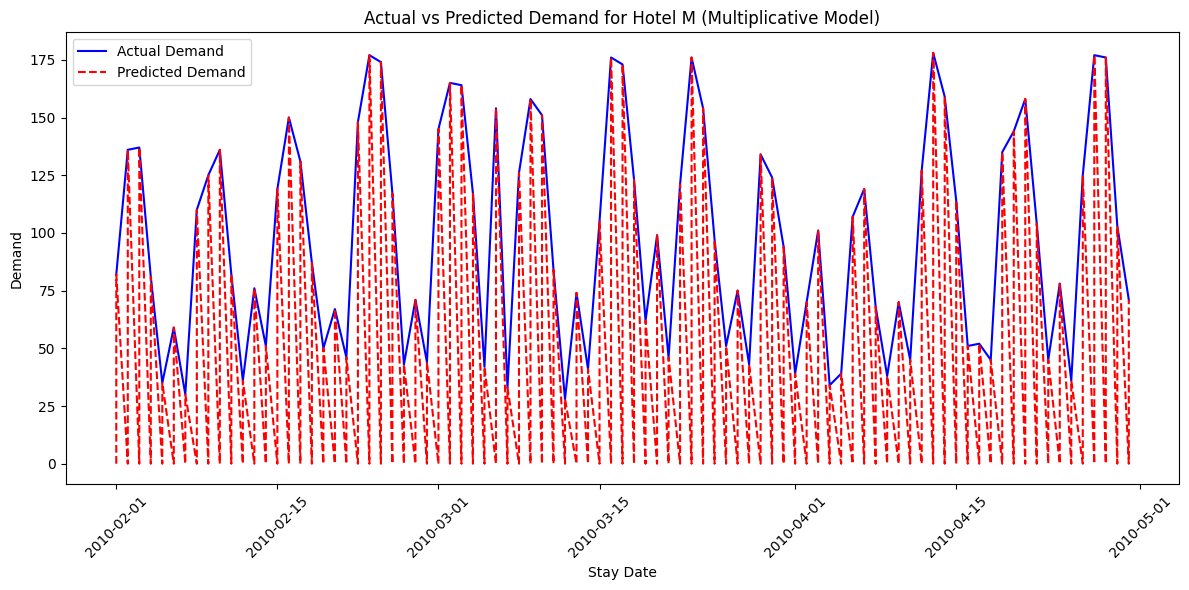

In [31]:
visualize_predictions(M_testset, 'final_demand', 'multiplicative_forecast', 'M', 'Multiplicative Model')

Actual vs Predicted Demand Visualization

The plot comparing actual demand to the forecast shows the multiplicative model often fails to follow the ups and downs of real bookings. While the predicted line sometimes matches the peaks of the actual demand, it frequently drops when the true demand increases, or misses sudden changes. The overall fit is poor, meaning this method struggles to adapt to the patterns and volatility seen in this hotel's data.